In [1]:
import polars as pl
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_ROOT = PROJECT_ROOT / "tennis_data"
data_path = DATA_ROOT / "Data"

In [3]:
votes = pl.read_parquet(data_path / "votes_clean.parquet")

print("Shape:", votes.shape)
print("Columns:")
print(votes.columns)

Shape: (35658, 4)
Columns:
['match_id', 'home_vote', 'away_vote', 'snapshot_date']


In [4]:
# Inspect vote snapshots for sample matches

sample_match_ids = (
    votes
    .select("match_id")
    .unique()
    .head(3)
)

sample_votes = (
    votes
    .join(sample_match_ids, on="match_id")
    .sort(["match_id", "snapshot_date"])
)

sample_votes

match_id,home_vote,away_vote,snapshot_date
i64,i64,i64,date
12180478,36,91,2024-03-21
12180478,36,91,2024-03-22
12181401,129,116,2024-03-22
12181401,129,116,2024-03-23
12210111,78,576,2024-03-31


In [5]:
# Keep only the latest vote snapshot for each match

votes_latest = (
    votes
    .sort(["match_id", "snapshot_date"])
    .group_by("match_id")
    .last()
)

print("Original rows:", votes.height)
print("Unique matches:", votes_latest.height)

votes_latest.head(10)

Original rows: 35658
Unique matches: 16873


match_id,home_vote,away_vote,snapshot_date
i64,i64,i64,date
11974049,420,68,2024-02-05
11974052,654,52,2024-02-03
11974053,272,61,2024-02-03
11974065,144,18,2024-02-05
11974066,124,579,2024-02-02
11974067,145,247,2024-02-03
11974068,157,160,2024-02-03
11974070,29,259,2024-02-04
11974071,100,158,2024-02-03


In [6]:
# Determine the majority user vote for each match

votes_majority = votes_latest.with_columns(
    pl.when(pl.col("home_vote") > pl.col("away_vote"))
      .then(pl.lit("home"))
      .when(pl.col("away_vote") > pl.col("home_vote"))
      .then(pl.lit("away"))
      .otherwise(pl.lit("tie"))
      .alias("majority_vote")
)

votes_majority.select([
    "match_id",
    "home_vote",
    "away_vote",
    "majority_vote"
]).head(10)

match_id,home_vote,away_vote,majority_vote
i64,i64,i64,str
11974049,420,68,"""home"""
11974052,654,52,"""home"""
11974053,272,61,"""home"""
11974065,144,18,"""home"""
11974066,124,579,"""away"""
11974067,145,247,"""away"""
11974068,157,160,"""away"""
11974070,29,259,"""away"""
11974071,100,158,"""away"""


In [8]:
# Load event data to identify the actual match winner

event = pl.read_parquet(data_path / "event.parquet")

print("Shape:", event.shape)
print("Columns:")
print(event.columns)

Shape: (35053, 12)
Columns:
['match_id', 'first_to_serve', 'home_team_seed', 'away_team_seed', 'custom_id', 'winner_code', 'default_period_count', 'start_datetime', 'match_slug', 'final_result_only', 'snapshot_date', 'match_datetime']


In [9]:
# Check winner_code values

print(
    event["winner_code"]
    .value_counts()
    .sort("winner_code")
)

shape: (3, 2)
┌─────────────┬───────┐
│ winner_code ┆ count │
│ ---         ┆ ---   │
│ i64         ┆ u32   │
╞═════════════╪═══════╡
│ null        ┆ 3049  │
│ 1           ┆ 16552 │
│ 2           ┆ 15452 │
└─────────────┴───────┘


In [10]:
# Inspect winner_code with match information

event.select([
    "match_id",
    "match_slug",
    "winner_code"
]).filter(
    pl.col("winner_code").is_not_null()
).head(20)

match_id,match_slug,winner_code
i64,str,i64
12017464,"""kuhl-salkova""",2
12018812,"""gokpinar-hardt""",2
12021601,"""jorda-sanchis-marchenko""",1
12017522,"""tubello-serban""",1
12019673,"""roura-llaverias-balus""",2
…,…,…
12017533,"""boisson-dodin""",1
11998448,"""mmoh-muller""",1
12002044,"""golubic-putintseva""",2


In [11]:
# Load home and away team data

home_team = pl.read_parquet(data_path / "home_team.parquet")
away_team = pl.read_parquet(data_path / "away_team.parquet")

print("Home team columns:")
print(home_team.columns)

print("\nAway team columns:")
print(away_team.columns)

Home team columns:
['match_id', 'name', 'slug', 'gender', 'user_count', 'residence', 'birthplace', 'height', 'weight', 'plays', 'turned_pro', 'current_prize', 'total_prize', 'player_id', 'current_rank', 'name_code', 'country', 'full_name', 'snapshot_date']

Away team columns:
['match_id', 'name', 'slug', 'gender', 'user_count', 'residence', 'birthplace', 'height', 'weight', 'plays', 'turned_pro', 'current_prize', 'total_prize', 'player_id', 'current_rank', 'name_code', 'country', 'full_name', 'snapshot_date']


In [12]:
# Compare home and away players with winner_code

winner_check = (
    event
    .select(["match_id", "match_slug", "winner_code"])
    .filter(pl.col("winner_code").is_not_null())
    .join(
        home_team.select([
            "match_id",
            pl.col("name").alias("home_player")
        ]).unique("match_id"),
        on="match_id",
        how="left"
    )
    .join(
        away_team.select([
            "match_id",
            pl.col("name").alias("away_player")
        ]).unique("match_id"),
        on="match_id",
        how="left"
    )
)

winner_check.head(10)

match_id,match_slug,winner_code,home_player,away_player
i64,str,i64,str,str
12017464,"""kuhl-salkova""",2,"""Kuhl C.""","""Salkova D."""
12018812,"""gokpinar-hardt""",2,null,"""Hardt N."""
12021601,"""jorda-sanchis-marchenko""",1,"""Jorda Sanchis D.""","""Marchenko I."""
12017522,"""tubello-serban""",1,"""Tubello A.""","""Șerban R."""
12019673,"""roura-llaverias-balus""",2,"""Balus I.""","""Roura Llaverias R."""
12017465,"""waltert-jorge""",1,"""Jorge F.""","""Waltert S."""
12019677,"""munk-mortensen-adaloglou""",1,"""Munk Mortensen R.""","""Adaloglou M."""
12016976,"""andreeva-yastremska""",1,"""Yastremska D.""","""Andreeva E."""
12017459,"""pawelski-lopez""",2,"""Lopez N.""","""Pawelski M."""


In [13]:
# Convert winner_code to actual winner side

actual_winners = (
    event
    .select(["match_id", "winner_code"])
    .filter(pl.col("winner_code").is_in([1, 2]))
    .with_columns(
        pl.when(pl.col("winner_code") == 1)
        .then(pl.lit("home"))
        .otherwise(pl.lit("away"))
        .alias("actual_winner")
    )
    .unique("match_id")
)

actual_winners.head(10)

match_id,winner_code,actual_winner
i64,i64,str
12042484,1,"""home"""
12049677,1,"""home"""
12087938,2,"""away"""
12136959,1,"""home"""
12144837,2,"""away"""
12166881,2,"""away"""
12188737,2,"""away"""
12211552,2,"""away"""
12148136,2,"""away"""


In [16]:
# Merge majority vote with actual match winner

comparison = (
    votes_majority
    .join(
        actual_winners,
        on="match_id",
        how="inner"
    )
    .with_columns(
        (pl.col("majority_vote") == pl.col("actual_winner"))
        .alias("correct_prediction")
    )
)

print("Matched games:", comparison.height)

comparison.select([
    "match_id",
    "home_vote",
    "away_vote",
    "majority_vote",
    "actual_winner",
    "correct_prediction"
]).head(10)

Matched games: 16266


match_id,home_vote,away_vote,majority_vote,actual_winner,correct_prediction
i64,i64,i64,str,str,bool
11974049,420,68,"""home""","""away""",false
11974052,654,52,"""home""","""away""",false
11974053,272,61,"""home""","""home""",true
11974065,144,18,"""home""","""home""",true
11974066,124,579,"""away""","""away""",true
11974067,145,247,"""away""","""away""",true
11974068,157,160,"""away""","""home""",false
11974070,29,259,"""away""","""away""",true
11974071,100,158,"""away""","""away""",true


In [17]:
# Calculate user majority-vote accuracy

total_matches = comparison.height
correct_matches = comparison.filter(
    pl.col("correct_prediction")
).height

incorrect_matches = total_matches - correct_matches

accuracy = (correct_matches / total_matches) * 100

print("Total matches:", total_matches)
print("Correct predictions:", correct_matches)
print("Incorrect predictions:", incorrect_matches)
print(f"Majority vote accuracy: {accuracy:.2f}%")

Total matches: 16266
Correct predictions: 10347
Incorrect predictions: 5919
Majority vote accuracy: 63.61%


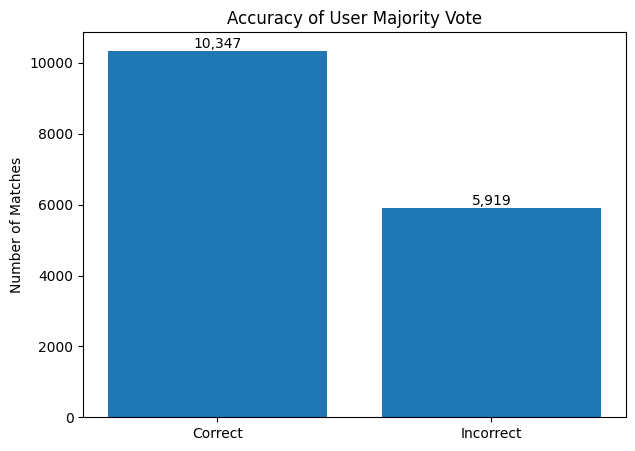

In [18]:
import matplotlib.pyplot as plt

labels = ["Correct", "Incorrect"]
values = [correct_matches, incorrect_matches]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values)

plt.title("Accuracy of User Majority Vote")
plt.ylabel("Number of Matches")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.show()

### Result

Out of 16,266 matches, the majority of user votes correctly predicted
the actual match winner in 10,347 matches.

**Majority Vote Accuracy: 63.61%**